In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from keras.layers import Input, Dense 
from keras.models import Model 
from keras.datasets import mnist 

In [2]:
(x_train, _), (x_test, _) = mnist.load_data() 
x_train = x_train.astype('float32') / 255. 
x_test = x_test.astype('float32') / 255. 
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) 
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [3]:
input_img = Input(shape=(784,)) 
encoded = Dense(32, activation='relu')(input_img) 
decoded = Dense(784, activation='sigmoid')(encoded) 
autoencoder = Model(input_img, decoded) 

In [4]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy') 
autoencoder.fit(x_train, x_train, 
    epochs=50, 
    batch_size=256, 
    shuffle=True, 
    validation_data=(x_test, x_test)) 
test_loss = autoencoder.evaluate(x_test, x_test) 
decoded_imgs = autoencoder.predict(x_test)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2797 - val_loss: 0.1929
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1710 - val_loss: 0.1530
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1436 - val_loss: 0.1335
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1273 - val_loss: 0.1196
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1162 - val_loss: 0.1109
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1091 - val_loss: 0.1050
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1040 - val_loss: 0.1007
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1005 - val_loss: 0.0979
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0982 - val_loss: 0.0962
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0968 - val_loss: 0.0950
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0959 - val_loss: 0.0943
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

In [5]:
threshold = 0.5 
correct_predictions = np.sum( 
    np.where(x_test >= threshold, 1, 0) == 
    np.where(decoded_imgs >= threshold, 1, 0) 
) 
total_pixels = x_test.shape[0] * x_test.shape[1] 
test_accuracy = correct_predictions / total_pixels 
print("Test Loss:", test_loss) 
print("Test Accuracy:", test_accuracy)

Test Loss: 0.0915144830942154
Test Accuracy: 0.971397831632653


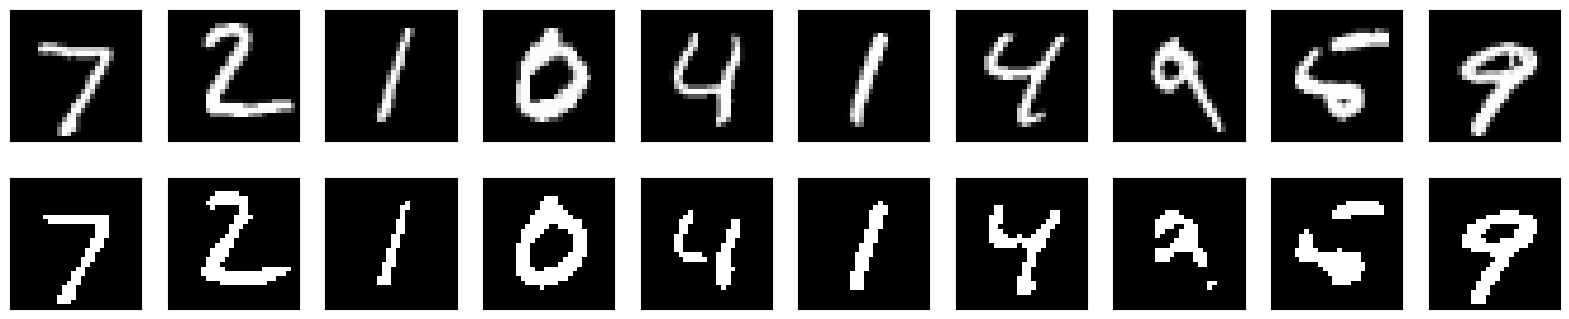

In [6]:
n = 10   
plt.figure(figsize=(20, 4)) 
for i in range(n): 
    ax = plt.subplot(2, n, i + 1) 
    plt.imshow(x_test[i].reshape(28, 28)) 
    plt.gray() 
    ax.get_xaxis().set_visible(False) 
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i + 1 + n) 
    reconstruction = decoded_imgs[i].reshape(28, 28) 
    plt.imshow(np.where(reconstruction >= threshold, 1.0, 0.0)) 
    plt.gray() 
    ax.get_xaxis().set_visible(False) 
    ax.get_yaxis().set_visible(False) 
plt.show()